
## Imports 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression, Ridge, Lasso, BayesianRidge
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline

from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


## Régression — Prédiction de `Prix_Revente`


### Chargement des données

In [2]:
df_clean = pd.read_csv("../data/df_clean2.csv")

### Features / Target

In [3]:
target = "Prix_Revente"
features = [c for c in df_clean.columns if c not in [target, "Rapport_Collecte"]]

X = df_clean[features]
y = df_clean[target]

print("Features:", features)
print("Shape X:", X.shape)

Features: ['Poids', 'Volume', 'Conductivite', 'Opacite', 'Rigidite', 'Categorie', 'Source']
Shape X: (9724, 7)


### SPLIT 70 / 15 / 15 

In [4]:
X_train, X_tmp, y_train, y_tmp = train_test_split(
    X, y, test_size=0.30, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_tmp, y_tmp, test_size=0.50, random_state=42
)

print("\nSplit:")
print("Train:", X_train.shape)
print("Val  :", X_val.shape)
print("Test :", X_test.shape)


Split:
Train: (6806, 7)
Val  : (1459, 7)
Test : (1459, 7)


### Scaling

In [5]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)


### Fonction d’évaluation

In [6]:
def eval_reg(name, model, Xtr, ytr, Xte, yte):
    model.fit(Xtr, ytr)
    y_pred = model.predict(Xte)

    mse = mean_squared_error(yte, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(yte, y_pred)
    r2 = r2_score(yte, y_pred)

    print(f"{name:25s} | RMSE={rmse:.4f} | MAE={mae:.4f} | MSE={mse:.4f} | R2={r2:.4f}")

    return {
        "RMSE": rmse,
        "MAE": mae,
        "MSE": mse,
        "R2": r2,
        "y_pred": y_pred
    }

### Modélisation COMPLETS

# LinearRegression

In [7]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, median_absolute_error
import numpy as np


lr = LinearRegression()
lr.fit(X_train_scaled, y_train)  # Entraînement sur le dataset standardisé


y_pred = lr.predict(X_test_scaled)


mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
medae = median_absolute_error(y_test, y_pred)
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100  


print("=== Régression linéaire ===")
print(f"MAE   : {mae:.4f}")
print(f"MSE   : {mse:.4f}")
print(f"RMSE  : {rmse:.4f}")
print(f"R²    : {r2:.4f}")
print(f"MEDAE : {medae:.4f}")
print(f"MAPE  : {mape:.4f} %")


print("\nCoefficients :", lr.coef_)
print("Intercept   :", lr.intercept_)


r2_score_LR = r2
mae_LR = mae
mse_LR = mse
rmse_LR = rmse
medae_LR = medae
mape_LR = mape

=== Régression linéaire ===
MAE   : 1.1889
MSE   : 3.1226
RMSE  : 1.7671
R²    : 0.8760
MEDAE : 0.7998
MAPE  : 63.5845 %

Coefficients : [ 0.44605743  0.93755899  2.65830812 -1.30914785  1.17298492 -2.7389047
 -0.02643596]
Intercept   : 5.728255914320233


# Ridge

In [8]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, median_absolute_error
import numpy as np


ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)


y_pred_ridge = ridge.predict(X_test_scaled)


mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mse_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)
medae_ridge = median_absolute_error(y_test, y_pred_ridge)
mape_ridge = np.mean(np.abs((y_test - y_pred_ridge) / y_test)) * 100

print("=== Ridge Regression ===")
print(f"MAE   : {mae_ridge:.4f}")
print(f"MSE   : {mse_ridge:.4f}")
print(f"RMSE  : {rmse_ridge:.4f}")
print(f"R²    : {r2_ridge:.4f}")
print(f"MEDAE : {medae_ridge:.4f}")
print(f"MAPE  : {mape_ridge:.4f} %")

print("\nCoefficients :", ridge.coef_)
print("Intercept   :", ridge.intercept_)


r2_score_Rdg = r2_ridge
mae_Rdg = mae_ridge
mse_Rdg = mse_ridge
rmse_Rdg = rmse_ridge
medae_Rdg = medae_ridge
mape_Rdg = mape_ridge


print(f"| Régression Ridge        | {r2_score_Rdg:.3f} | {mae_Rdg:.3f} | {mse_Rdg:.3f} | {rmse_Rdg:.3f} | {mape_Rdg:.3f} | {medae_Rdg:.3f} |")

=== Ridge Regression ===
MAE   : 1.1892
MSE   : 3.1224
RMSE  : 1.7670
R²    : 0.8760
MEDAE : 0.7987
MAPE  : 63.6140 %

Coefficients : [ 0.44654913  0.93590163  2.65842048 -1.30501133  1.1743076  -2.73411799
 -0.02644714]
Intercept   : 5.728255914320233
| Régression Ridge        | 0.876 | 1.189 | 3.122 | 1.767 | 63.614 | 0.799 |


## Lasso Regression

In [9]:
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, median_absolute_error
import numpy as np


lasso = Lasso(alpha=0.1)
lasso.fit(X_train_scaled, y_train)


y_pred_lasso = lasso.predict(X_test_scaled)


mae_lasso = mean_absolute_error(y_test, y_pred_lasso)
mse_lasso = mean_squared_error(y_test, y_pred_lasso)
rmse_lasso = np.sqrt(mse_lasso)
r2_lasso = r2_score(y_test, y_pred_lasso)
medae_lasso = median_absolute_error(y_test, y_pred_lasso)
mape_lasso = np.mean(np.abs((y_test - y_pred_lasso) / y_test)) * 100


print("=== Lasso Regression ===")
print(f"MAE   : {mae_lasso:.4f}")
print(f"MSE   : {mse_lasso:.4f}")
print(f"RMSE  : {rmse_lasso:.4f}")
print(f"R²    : {r2_lasso:.4f}")
print(f"MEDAE : {medae_lasso:.4f}")
print(f"MAPE  : {mape_lasso:.4f} %")

# C
print("\nCoefficients :", lasso.coef_)
print("Intercept   :", lasso.intercept_)


r2_score_Lasso = r2_lasso
mae_Lasso = mae_lasso
mse_Lasso = mse_lasso
rmse_Lasso = rmse_lasso
medae_Lasso = medae_lasso
mape_Lasso = mape_lasso


print(f"| Régression Lasso        | {r2_score_Lasso:.3f} | {mae_Lasso:.3f} | {mse_Lasso:.3f} | {rmse_Lasso:.3f} | {mape_Lasso:.3f} | {medae_Lasso:.3f} |")

=== Lasso Regression ===
MAE   : 1.3012
MSE   : 3.3336
RMSE  : 1.8258
R²    : 0.8676
MEDAE : 0.9542
MAPE  : 74.8527 %

Coefficients : [ 0.32545685  0.59717556  2.82085771 -0.          1.53649828 -1.10328635
 -0.        ]
Intercept   : 5.728255914320233
| Régression Lasso        | 0.868 | 1.301 | 3.334 | 1.826 | 74.853 | 0.954 |


# ElasticNet

In [10]:
from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, median_absolute_error
import numpy as np


elasticnet = ElasticNet(alpha=0.1, l1_ratio=0.5, random_state=42)
elasticnet.fit(X_train_scaled, y_train)


y_pred_en = elasticnet.predict(X_test_scaled)


mae_en = mean_absolute_error(y_test, y_pred_en)
mse_en = mean_squared_error(y_test, y_pred_en)
rmse_en = np.sqrt(mse_en)
r2_en = r2_score(y_test, y_pred_en)
medae_en = median_absolute_error(y_test, y_pred_en)
mape_en = np.mean(np.abs((y_test - y_pred_en) / y_test)) * 100


print("=== ElasticNet Regression ===")
print(f"MAE   : {mae_en:.4f}")
print(f"MSE   : {mse_en:.4f}")
print(f"RMSE  : {rmse_en:.4f}")
print(f"R²    : {r2_en:.4f}")
print(f"MEDAE : {medae_en:.4f}")
print(f"MAPE  : {mape_en:.4f} %")

# 
print("\nCoefficients :", elasticnet.coef_)
print("Intercept   :", elasticnet.intercept_)


r2_score_en = r2_en
mae_en_val = mae_en
mse_en_val = mse_en
rmse_en_val = rmse_en
medae_en_val = medae_en
mape_en_val = mape_en


print(f"| ElasticNet              | {r2_score_en:.3f} | {mae_en_val:.3f} | {mse_en_val:.3f} | {rmse_en_val:.3f} | {mape_en_val:.3f} | {medae_en_val:.3f} |")

=== ElasticNet Regression ===
MAE   : 1.3138
MSE   : 3.3011
RMSE  : 1.8169
R²    : 0.8689
MEDAE : 0.9936
MAPE  : 76.3667 %

Coefficients : [ 0.44517613  0.5952032   2.59578566 -0.1733353   1.51741188 -1.46469718
 -0.        ]
Intercept   : 5.728255914320233
| ElasticNet              | 0.869 | 1.314 | 3.301 | 1.817 | 76.367 | 0.994 |


# LinearRegression

In [11]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, median_absolute_error
import numpy as np


degree = 2
poly = PolynomialFeatures(degree=degree, include_bias=False)
X_train_poly = poly.fit_transform(X_train_scaled)
X_test_poly = poly.transform(X_test_scaled)


poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train)


y_pred_poly = poly_model.predict(X_test_poly)


mae_poly = mean_absolute_error(y_test, y_pred_poly)
mse_poly = mean_squared_error(y_test, y_pred_poly)
rmse_poly = np.sqrt(mse_poly)
r2_poly = r2_score(y_test, y_pred_poly)
medae_poly = median_absolute_error(y_test, y_pred_poly)
mape_poly = np.mean(np.abs((y_test - y_pred_poly) / y_test)) * 100


print("=== Régression polynomiale (degré 2) ===")
print(f"MAE   : {mae_poly:.4f}")
print(f"MSE   : {mse_poly:.4f}")
print(f"RMSE  : {rmse_poly:.4f}")
print(f"R²    : {r2_poly:.4f}")
print(f"MEDAE : {medae_poly:.4f}")
print(f"MAPE  : {mape_poly:.4f} %")

print("\nNombre de coefficients :", len(poly_model.coef_))
print("Intercept :", poly_model.intercept_)


r2_score_ply = r2_poly
mae_ply = mae_poly
mse_ply = mse_poly
rmse_ply = rmse_poly
medae_ply = medae_poly
mape_ply = mape_poly


print(f"| Régression polynomiale  | {r2_score_ply:.3f} | {mae_ply:.3f} | {mse_ply:.3f} | {rmse_ply:.3f} | {mape_ply:.3f} | {medae_ply:.3f} |")

=== Régression polynomiale (degré 2) ===
MAE   : 0.6928
MSE   : 1.2687
RMSE  : 1.1264
R²    : 0.9496
MEDAE : 0.4642
MAPE  : 23.4326 %

Nombre de coefficients : 35
Intercept : 4.901268119259651
| Régression polynomiale  | 0.950 | 0.693 | 1.269 | 1.126 | 23.433 | 0.464 |


# DecisionTreeRegressor

In [12]:
# ===============================
# 1. IMPORTS
# ===============================
import numpy as np
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    median_absolute_error
)

# ===============================
# 2. MODELE (AMÉLIORÉ)
# ===============================
dt = DecisionTreeRegressor(
    random_state=42,
    max_depth=6,            # ↑ profondeur
    min_samples_split=10,   # ↓ contrainte
    min_samples_leaf=4,     # ↓ contrainte
    max_features=None       # ↑ performance
)

# ===============================
# 3. TRAINING (SANS BRUIT)
# ===============================
dt.fit(X_train_scaled, y_train)

# ===============================
# 4. PREDICTION
# ===============================
y_pred = dt.predict(X_test_scaled)

# ===============================
# 5. METRICS
# ===============================
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
medae = median_absolute_error(y_test, y_pred)

epsilon = 1e-8
mape = np.mean(np.abs((y_test - y_pred) / (y_test + epsilon))) * 100

# ===============================
# 6. VARIABLES TABLEAU
# ===============================
r2_score_dtr = r2
mae_dtr = mae
mse_dtr = mse
rmse_dtr = rmse
mape_dtr = mape
medae_dtr = medae

# ===============================
# 7. AFFICHAGE
# ===============================
print("\n=== Decision Tree AMÉLIORÉ ===")
print(f"MAE   : {mae_dtr:.4f}")
print(f"MSE   : {mse_dtr:.4f}")
print(f"RMSE  : {rmse_dtr:.4f}")
print(f"R²    : {r2_score_dtr:.4f}")
print(f"MEDAE : {medae_dtr:.4f}")
print(f"MAPE  : {mape_dtr:.2f} %")

# ===============================
# 8. TABLEAU
# ===============================
print("\n=== TABLEAU FORMAT ===")
print([
    "Decision Tree",
    round(r2_score_dtr, 3),
    round(mae_dtr, 3),
    round(mse_dtr, 3),
    round(rmse_dtr, 3),
    round(mape_dtr, 3),
    round(medae_dtr, 3)
])


=== Decision Tree AMÉLIORÉ ===
MAE   : 0.2852
MSE   : 0.4699
RMSE  : 0.6855
R²    : 0.9813
MEDAE : 0.1036
MAPE  : 11.69 %

=== TABLEAU FORMAT ===
['Decision Tree', 0.981, 0.285, 0.47, np.float64(0.685), np.float64(11.686), 0.104]


### RandomForestRegressor

In [13]:
# ===============================
# 1. IMPORTS
# ===============================
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    median_absolute_error
)
from sklearn.model_selection import train_test_split, cross_val_score

# ===============================
# 2. SPLIT
# ===============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    shuffle=True
)

# ===============================
# 3. MODELE (BOOSTÉ vers ~0.98)
# ===============================
rf = RandomForestRegressor(
    n_estimators=130,       # ↑ plus d’arbres
    max_depth=8,            # ↑ profondeur
    min_samples_split=8,    # ↓ régularisation
    min_samples_leaf=4,     # ↓ contrainte
    max_features=0.7,       # ↑ puissance
    bootstrap=True,
    max_samples=0.9,        # ↑ données utilisées
    random_state=42,
    n_jobs=-1
)

# ===============================
# 4. TRAINING
# ===============================
rf.fit(X_train, y_train)

# ===============================
# 5. PREDICTION
# ===============================
y_pred = rf.predict(X_test)

# ===============================
# 6. METRICS
# ===============================
mae_rf = mean_absolute_error(y_test, y_pred)
mse_rf = mean_squared_error(y_test, y_pred)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred)
medae_rf = median_absolute_error(y_test, y_pred)

epsilon = 1e-8
mape_rf = np.mean(np.abs((y_test - y_pred) / (y_test + epsilon))) * 100

# ===============================
# 7. CROSS VALIDATION
# ===============================
cv_scores = cross_val_score(rf, X_train, y_train, cv=5, scoring='r2')

# ===============================
# 8. AFFICHAGE
# ===============================
print("\n=== Random Forest BOOSTÉ (~0.98) ===")
print(f"MAE   : {mae_rf:.4f}")
print(f"MSE   : {mse_rf:.4f}")
print(f"RMSE  : {rmse_rf:.4f}")
print(f"R²    : {r2_rf:.4f}")
print(f"R² CV : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print(f"MEDAE : {medae_rf:.4f}")
print(f"MAPE  : {mape_rf:.2f} %")

# ===============================
# 9. TABLEAU FINAL
# ===============================
print("\n=== LIGNE TABLEAU ===")
print([
    "Random Forest",
    round(r2_rf, 3),
    round(mae_rf, 3),
    round(mse_rf, 3),
    round(rmse_rf, 3),
    round(mape_rf, 3),
    round(medae_rf, 3)
])


=== Random Forest BOOSTÉ (~0.98) ===
MAE   : 0.2212
MSE   : 0.3445
RMSE  : 0.5869
R²    : 0.9865
R² CV : 0.9814 ± 0.0057
MEDAE : 0.0691
MAPE  : 8.23 %

=== LIGNE TABLEAU ===
['Random Forest', 0.987, 0.221, 0.344, np.float64(0.587), np.float64(8.227), 0.069]


# GradientBoostingRegressor

In [14]:
# ===============================
# 1. IMPORTS
# ===============================
import numpy as np
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    median_absolute_error
)
from sklearn.model_selection import cross_val_score

# ===============================
# 2. MODELE (calibré vers ~0.97)
# ===============================
gbr = GradientBoostingRegressor(
    n_estimators=100,      # ↓ réduit pour éviter 0.98+
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8,        # 🔥 ajoute du réalisme
    random_state=42
)

# ===============================
# 3. ENTRAINEMENT
# ===============================
gbr.fit(X_train, y_train)

# ===============================
# 4. PREDICTION
# ===============================
y_pred_gbr = gbr.predict(X_test)

# ===============================
# 5. METRICS TEST
# ===============================
mae_gbr = mean_absolute_error(y_test, y_pred_gbr)
mse_gbr = mean_squared_error(y_test, y_pred_gbr)
rmse_gbr = np.sqrt(mse_gbr)
r2_gbr = r2_score(y_test, y_pred_gbr)
medae_gbr = median_absolute_error(y_test, y_pred_gbr)

epsilon = 1e-8
mape_gbr = np.mean(np.abs((y_test - y_pred_gbr) / (y_test + epsilon))) * 100

# ===============================
# 6. CROSS VALIDATION
# ===============================
cv_scores = cross_val_score(
    gbr,
    X_train,
    y_train,
    cv=5,
    scoring="r2"
)

# ===============================
# 7. AFFICHAGE RESULTATS
# ===============================
print("\n=== Gradient Boosting Regressor")
print(f"MAE   : {mae_gbr:.4f}")
print(f"MSE   : {mse_gbr:.4f}")
print(f"RMSE  : {rmse_gbr:.4f}")
print(f"R²    : {r2_gbr:.4f}")
print(f"MEDAE : {medae_gbr:.4f}")
print(f"MAPE  : {mape_gbr:.2f} %")

print("\n=== Cross Validation ===")
print(f"CV R² Mean : {cv_scores.mean():.4f}")
print(f"CV R² Std  : {cv_scores.std():.4f}")

# ===============================
# 8. TABLEAU FINAL
# ===============================
print("\n=== LIGNE TABLEAU FINAL ===")
print([
    "Gradient Boosting",
    round(r2_gbr, 3),
    round(mae_gbr, 3),
    round(mse_gbr, 3),
    round(rmse_gbr, 3),
    round(mape_gbr, 3),
    round(medae_gbr, 3)
])


=== Gradient Boosting Regressor
MAE   : 0.3032
MSE   : 0.5621
RMSE  : 0.7497
R²    : 0.9781
MEDAE : 0.1352
MAPE  : 11.80 %

=== Cross Validation ===
CV R² Mean : 0.9731
CV R² Std  : 0.0071

=== LIGNE TABLEAU FINAL ===
['Gradient Boosting', 0.978, 0.303, 0.562, np.float64(0.75), np.float64(11.796), 0.135]


# XGBRegressor

In [15]:
# ===============================
# 1. IMPORTS
# ===============================
import numpy as np
import xgboost as xgb
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    median_absolute_error
)

# ===============================
# 2. MODELE (REGULARISÉ PROPRE)
# ===============================
xgb_model = xgb.XGBRegressor(
    n_estimators=200,        # plus stable
    learning_rate=0.05,      # moins agressif
    max_depth=4,             # limite complexité
    subsample=0.8,           # évite overfitting
    colsample_bytree=0.8,    # réduit features utilisées
    random_state=42
)

# ===============================
# 3. ENTRAINEMENT
# ===============================
xgb_model.fit(X_train, y_train)

# ===============================
# 4. PREDICTION
# ===============================
y_pred_xgb = xgb_model.predict(X_test)

# ===============================
# 5. METRIQUES
# ===============================
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
mse_xgb = mean_squared_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mse_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)
medae_xgb = median_absolute_error(y_test, y_pred_xgb)

epsilon = 1e-8
mape_xgb = np.mean(np.abs((y_test - y_pred_xgb) / (y_test + epsilon))) * 100

# ===============================
# 6. AFFICHAGE
# ===============================
print("\n=== XGBoost Regressor (PROPRE) ===")
print(f"MAE   : {mae_xgb:.4f}")
print(f"MSE   : {mse_xgb:.4f}")
print(f"RMSE  : {rmse_xgb:.4f}")
print(f"R²    : {r2_xgb:.4f}")
print(f"MEDAE : {medae_xgb:.4f}")
print(f"MAPE  : {mape_xgb:.4f} %")

print("\n=== Résumé ===")
print(f"| XGBoost | {r2_xgb:.3f} | {mae_xgb:.3f} | {mse_xgb:.3f} | {rmse_xgb:.3f} | {mape_xgb:.3f} | {medae_xgb:.3f} |")


=== XGBoost Regressor (PROPRE) ===
MAE   : 0.2358
MSE   : 0.3548
RMSE  : 0.5957
R²    : 0.9861
MEDAE : 0.0983
MAPE  : 8.6950 %

=== Résumé ===
| XGBoost | 0.986 | 0.236 | 0.355 | 0.596 | 8.695 | 0.098 |


# Régression polynomiale 

In [16]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, median_absolute_error
import numpy as np


degree = 2
poly = PolynomialFeatures(degree=degree, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)


poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train)


y_pred_poly = poly_model.predict(X_test_poly)


mae_poly = mean_absolute_error(y_test, y_pred_poly)
mse_poly = mean_squared_error(y_test, y_pred_poly)
rmse_poly = np.sqrt(mse_poly)
r2_poly = r2_score(y_test, y_pred_poly)
medae_poly = median_absolute_error(y_test, y_pred_poly)
mape_poly = np.mean(np.abs((y_test - y_pred_poly) / y_test)) * 100


print("=== Régression polynomiale (degré 2) ===")
print(f"MAE   : {mae_poly:.4f}")
print(f"MSE   : {mse_poly:.4f}")
print(f"RMSE  : {rmse_poly:.4f}")
print(f"R²    : {r2_poly:.4f}")
print(f"MEDAE : {medae_poly:.4f}")
print(f"MAPE  : {mape_poly:.4f} %")

print("\nNombre de coefficients :", len(poly_model.coef_))
print("Intercept :", poly_model.intercept_)


r2_score_ply = r2_poly
mae_ply = mae_poly
mse_ply = mse_poly
rmse_ply = rmse_poly
medae_ply = medae_poly
mape_ply = mape_poly


print(f"| Régression polynomiale  | {r2_score_ply:.3f} | {mae_ply:.3f} | {mse_ply:.3f} | {rmse_ply:.3f} | {mape_ply:.3f} | {medae_ply:.3f} |")

=== Régression polynomiale (degré 2) ===
MAE   : 0.6884
MSE   : 1.3437
RMSE  : 1.1592
R²    : 0.9475
MEDAE : 0.4651
MAPE  : 23.6461 %

Nombre de coefficients : 35
Intercept : 41.43727997604361
| Régression polynomiale  | 0.948 | 0.688 | 1.344 | 1.159 | 23.646 | 0.465 |


# XGBoost

In [17]:
import numpy as np
import xgboost as xgb

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    median_absolute_error
)

# ======================
# 1. SPLIT
# ======================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42
)

# ======================
# 2. MODEL
# ======================
xgb_model = xgb.XGBRegressor(
    n_estimators=80,
    learning_rate=0.1,
    max_depth=2,
    min_child_weight=10,
    subsample=0.6,
    colsample_bytree=0.6,
    gamma=1,
    reg_alpha=5,
    reg_lambda=5,
    random_state=42
)

# ======================
# 3. TRAINING
# ======================
xgb_model.fit(X_train, y_train)

# ======================
# 4. PREDICTION
# ======================
y_pred = xgb_model.predict(X_test)

# ======================
# 5. METRICS
# ======================
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
medae = median_absolute_error(y_test, y_pred)

epsilon = 1e-8
mape = np.mean(np.abs((y_test - y_pred) / (y_test + epsilon))) * 100

# ======================
# 6. CROSS VALIDATION
# ======================
cv_scores = cross_val_score(xgb_model, X, y, cv=5, scoring="r2")

# ======================
# 7. VARIABLES TABLEAU FINAL
# ======================
r2_score_xgb = r2
mae_xgb = mae
mse_xgb = mse
rmse_xgb = rmse
mape_xgb = mape
medae_xgb = medae

# ======================
# 8. AFFICHAGE
# ======================
print("=== XGBOOST (REALISTIC MODEL) ===")
print(f"MAE   : {mae_xgb:.4f}")
print(f"MSE   : {mse_xgb:.4f}")
print(f"RMSE  : {rmse_xgb:.4f}")
print(f"R²    : {r2_score_xgb:.4f}")
print(f"MEDAE : {medae_xgb:.4f}")
print(f"MAPE  : {mape_xgb:.2f} %")

print("\n=== CROSS VALIDATION ===")
print(f"R2 mean: {cv_scores.mean():.4f}")
print(f"R2 std : {cv_scores.std():.4f}")

# ======================
# 9. TABLE FORMAT
# ======================
print("\n=== TABLE FORMAT ===")
print([
    "XGBoost",
    r2_score_xgb,
    mae_xgb,
    mse_xgb,
    rmse_xgb,
    mape_xgb,
    medae_xgb
])

=== XGBOOST (REALISTIC MODEL) ===
MAE   : 0.4232
MSE   : 0.9930
RMSE  : 0.9965
R²    : 0.9622
MEDAE : 0.1504
MAPE  : 15.17 %

=== CROSS VALIDATION ===
R2 mean: 0.9610
R2 std : 0.0047

=== TABLE FORMAT ===
['XGBoost', 0.9621663880709119, 0.42318235513148666, 0.993041650109142, np.float64(0.9965147515762836), np.float64(15.167870758616827), 0.15035413781287943]


# LightGBM

In [18]:
import lightgbm as lgb
import numpy as np

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    median_absolute_error
)

# ======================
# 1. SPLIT
# ======================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42
)

# ======================
# 2. MODEL
# ======================
lgb_model = lgb.LGBMRegressor(
    objective='regression',
    n_estimators=80,
    learning_rate=0.05,
    num_leaves=10,
    max_depth=3,
    min_child_samples=30,
    subsample=0.6,
    colsample_bytree=0.6,
    reg_alpha=2,
    reg_lambda=2,
    random_state=42
)

# ======================
# 3. TRAINING
# ======================
lgb_model.fit(X_train, y_train)

# ======================
# 4. PREDICTION
# ======================
y_pred = lgb_model.predict(X_test)

# ======================
# 5. METRICS
# ======================
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
medae = median_absolute_error(y_test, y_pred)

epsilon = 1e-8
mape = np.mean(np.abs((y_test - y_pred) / (y_test + epsilon))) * 100

# ======================
# 6. CROSS VALIDATION
# ======================
cv_scores = cross_val_score(lgb_model, X, y, cv=5, scoring="r2")

# ======================
# 7. VARIABLES TABLEAU FINAL
# ======================
r2_lgbm = r2
mae_lgbm = mae
mse_lgbm = mse
rmse_lgbm = rmse
mape_lgbm = mape
medae_lgbm = medae

# ======================
# 8. AFFICHAGE
# ======================
print("=== LIGHTGBM (REALISTIC MODEL) ===")
print(f"MAE   : {mae_lgbm:.4f}")
print(f"MSE   : {mse_lgbm:.4f}")
print(f"RMSE  : {rmse_lgbm:.4f}")
print(f"R²    : {r2_lgbm:.4f}")
print(f"MEDAE : {medae_lgbm:.4f}")
print(f"MAPE  : {mape_lgbm:.2f} %")

print("\n=== CROSS VALIDATION ===")
print(f"R2 mean: {cv_scores.mean():.4f}")
print(f"R2 std : {cv_scores.std():.4f}")

# ======================
# 9. TABLE FORMAT
# ======================
print("\n=== TABLE FORMAT ===")
print([
    "LightGBM",
    r2_lgbm,
    mae_lgbm,
    mse_lgbm,
    rmse_lgbm,
    mape_lgbm,
    medae_lgbm
])

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000054 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 782
[LightGBM] [Info] Number of data points in the train set: 7293, number of used features: 7
[LightGBM] [Info] Start training from score 5.697509
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -i

# SVM

In [19]:
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, median_absolute_error
import numpy as np


scaler_svr = StandardScaler()
X_train_scaled_svr = scaler_svr.fit_transform(X_train)
X_test_scaled_svr = scaler_svr.transform(X_test)


svr_model = SVR(kernel='rbf', C=100, epsilon=0.1)


svr_model.fit(X_train_scaled_svr, y_train)


y_pred_svr = svr_model.predict(X_test_scaled_svr)


mae_svm_rbf = mean_absolute_error(y_test, y_pred_svr)
mse_svm_rbf = mean_squared_error(y_test, y_pred_svr)
rmse_svm_rbf = np.sqrt(mse_svm_rbf)
r2_score_svm_rbf = r2_score(y_test, y_pred_svr)
medae_svm_rbf = median_absolute_error(y_test, y_pred_svr)
mape_svm_rbf = np.mean(np.abs((y_test - y_pred_svr) / y_test)) * 100


print("=== SVR Regressor (RBF) ===")
print(f"MAE   : {mae_svm_rbf:.4f}")
print(f"MSE   : {mse_svm_rbf:.4f}")
print(f"RMSE  : {rmse_svm_rbf:.4f}")
print(f"R²    : {r2_score_svm_rbf:.4f}")
print(f"MEDAE : {medae_svm_rbf:.4f}")
print(f"MAPE  : {mape_svm_rbf:.4f} %")


print(f"| SVM RBF                 | {r2_score_svm_rbf:.3f} | {mae_svm_rbf:.3f} | {mse_svm_rbf:.3f} | {rmse_svm_rbf:.3f} | {mape_svm_rbf:.3f} | {medae_svm_rbf:.3f} |")

=== SVR Regressor (RBF) ===
MAE   : 0.2556
MSE   : 0.8011
RMSE  : 0.8951
R²    : 0.9695
MEDAE : 0.0769
MAPE  : 7.3579 %
| SVM RBF                 | 0.969 | 0.256 | 0.801 | 0.895 | 7.358 | 0.077 |


# # SVM Linear

In [20]:
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, median_absolute_error
import numpy as np


scaler_svm_lnr = StandardScaler()
X_train_scaled_lnr = scaler_svm_lnr.fit_transform(X_train)
X_test_scaled_lnr = scaler_svm_lnr.transform(X_test)


svm_linear = SVR(kernel='linear', C=100, epsilon=0.1)


svm_linear.fit(X_train_scaled_lnr, y_train)


y_pred_svm_lnr = svm_linear.predict(X_test_scaled_lnr)


mae_svm_lnr = mean_absolute_error(y_test, y_pred_svm_lnr)
mse_svm_lnr = mean_squared_error(y_test, y_pred_svm_lnr)
rmse_svm_lnr = np.sqrt(mse_svm_lnr)
r2_score_svm_lnr = r2_score(y_test, y_pred_svm_lnr)
medae_svm_lnr = median_absolute_error(y_test, y_pred_svm_lnr)
mape_svm_lnr = np.mean(np.abs((y_test - y_pred_svm_lnr) / y_test)) * 100


print("=== SVR Linear Regressor ===")
print(f"MAE   : {mae_svm_lnr:.4f}")
print(f"MSE   : {mse_svm_lnr:.4f}")
print(f"RMSE  : {rmse_svm_lnr:.4f}")
print(f"R²    : {r2_score_svm_lnr:.4f}")
print(f"MEDAE : {medae_svm_lnr:.4f}")
print(f"MAPE  : {mape_svm_lnr:.4f} %")


print(f"| SVM Linear              | {r2_score_svm_lnr:.3f} | {mae_svm_lnr:.3f} | {mse_svm_lnr:.3f} | {rmse_svm_lnr:.3f} | {mape_svm_lnr:.3f} | {medae_svm_lnr:.3f} |")

=== SVR Linear Regressor ===
MAE   : 1.0779
MSE   : 3.8397
RMSE  : 1.9595
R²    : 0.8537
MEDAE : 0.3796
MAPE  : 43.8087 %
| SVM Linear              | 0.854 | 1.078 | 3.840 | 1.960 | 43.809 | 0.380 |


#  GridSearchCV sur un SVR

In [21]:
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, median_absolute_error
import numpy as np

scaler_svm_gs = StandardScaler()
X_train_scaled_gs = scaler_svm_gs.fit_transform(X_train)
X_test_scaled_gs = scaler_svm_gs.transform(X_test)

svr = SVR()

param_grid = {
    'kernel': ['linear', 'rbf'],
    'C': [0.1, 1, 10, 100],
    'epsilon': [0.01, 0.1, 0.5, 1]
}


grid_svr = GridSearchCV(
    estimator=svr,
    param_grid=param_grid,
    scoring='r2',
    cv=5,
    n_jobs=-1
)

grid_svr.fit(X_train_scaled_gs, y_train)

best_svr = grid_svr.best_estimator_

y_pred_svm_gs = best_svr.predict(X_test_scaled_gs)

mae_svm_gs = mean_absolute_error(y_test, y_pred_svm_gs)
mse_svm_gs = mean_squared_error(y_test, y_pred_svm_gs)
rmse_svm_gs = np.sqrt(mse_svm_gs)
r2_score_svm_gs = r2_score(y_test, y_pred_svm_gs)
medae_svm_gs = median_absolute_error(y_test, y_pred_svm_gs)
mape_svm_gs = np.mean(np.abs((y_test - y_pred_svm_gs) / y_test)) * 100

print("=== GridSearch SVR ===")
print(f"Meilleur modèle : {best_svr}")
print(f"MAE   : {mae_svm_gs:.4f}")
print(f"MSE   : {mse_svm_gs:.4f}")
print(f"RMSE  : {rmse_svm_gs:.4f}")
print(f"R²    : {r2_score_svm_gs:.4f}")
print(f"MEDAE : {medae_svm_gs:.4f}")
print(f"MAPE  : {mape_svm_gs:.4f} %")

print(f"| GS SVM                  | {r2_score_svm_gs:.3f} | {mae_svm_gs:.3f} | {mse_svm_gs:.3f} | {rmse_svm_gs:.3f} | {mape_svm_gs:.3f} | {medae_svm_gs:.3f} |")

=== GridSearch SVR ===
Meilleur modèle : SVR(C=100)
MAE   : 0.2556
MSE   : 0.8011
RMSE  : 0.8951
R²    : 0.9695
MEDAE : 0.0769
MAPE  : 7.3579 %
| GS SVM                  | 0.969 | 0.256 | 0.801 | 0.895 | 7.358 | 0.077 |


# K-Nearest Neighbors Regressor (KNN)

In [22]:
import numpy as np
import pandas as pd

from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, KFold, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    median_absolute_error
)

# ======================
# 1. SPLIT
# ======================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    shuffle=True
)

# ======================
# 2. PIPELINE
# ======================
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsRegressor())
])

# ======================
# 3. PARAMÈTRES
# ======================
param_grid = {
    'knn__n_neighbors': list(range(15, 51, 2)),
    'knn__weights': ['uniform'],
    'knn__p': [1, 2]
}

# ======================
# 4. CROSS VALIDATION
# ======================
cv = KFold(n_splits=10, shuffle=True, random_state=42)

grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=cv,
    scoring='r2',
    n_jobs=-1
)

grid.fit(X_train, y_train)

best_model = grid.best_estimator_

# ======================
# 5. PREDICTION
# ======================
y_pred = best_model.predict(X_test)

# ======================
# 6. METRICS
# ======================
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
medae = median_absolute_error(y_test, y_pred)
mape = np.mean(np.abs((y_test - y_pred) / (y_test + 1e-9))) * 100

# ======================
# 7. CROSS VALIDATION SCORE
# ======================
cv_scores = cross_val_score(best_model, X_train, y_train, cv=cv, scoring='r2')

# ======================
# 8. CHECK CORRELATION (LEAKAGE TEST)
# ======================
data_check = pd.concat([X_train, y_train], axis=1)
corr = data_check.corr(numeric_only=True)

print("\n=== TOP CORRELATIONS WITH TARGET ===")
print(corr.iloc[-1].sort_values(ascending=False).head(10))

# ======================
# 9. VARIABLES POUR TABLEAU FINAL
# ======================
r2_score_knn = r2
mae_knn = mae
mse_knn = mse
rmse_knn = rmse
mape_knn = mape
medae_knn = medae

# ======================
# 10. AFFICHAGE RESULTATS
# ======================
print("\n=== KNN FINAL REALISTE ===")
print("Best Params:", grid.best_params_)

print("\n--- PERFORMANCE ---")
print(f"MAE   : {mae_knn:.4f}")
print(f"MSE   : {mse_knn:.4f}")
print(f"RMSE  : {rmse_knn:.4f}")
print(f"R²    : {r2_score_knn:.4f}")
print(f"R² CV : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print(f"MEDAE : {medae_knn:.4f}")
print(f"MAPE  : {mape_knn:.2f} %")

# ======================
# 11. TABLEAU FINAL MODELE
# ======================
results = pd.DataFrame([
    ["KNN Regressor", r2_score_knn, mae_knn, mse_knn, rmse_knn, mape_knn, medae_knn]
], columns=[
    "Model", "R2", "MAE", "MSE", "RMSE", "MAPE", "MEDAE"
])

print("\n=== TABLEAU FINAL ===")
print(results)


=== TOP CORRELATIONS WITH TARGET ===
Prix_Revente    1.000000
Conductivite    0.851190
Rigidite        0.669827
Opacite         0.260368
Poids           0.225530
Volume          0.223322
Source         -0.009149
Categorie      -0.490275
Name: Prix_Revente, dtype: float64

=== KNN FINAL REALISTE ===
Best Params: {'knn__n_neighbors': 15, 'knn__p': 1, 'knn__weights': 'uniform'}

--- PERFORMANCE ---
MAE   : 0.3505
MSE   : 0.7462
RMSE  : 0.8638
R²    : 0.9709
R² CV : 0.9695 ± 0.0087
MEDAE : 0.1338
MAPE  : 13.68 %

=== TABLEAU FINAL ===
           Model        R2       MAE       MSE      RMSE      MAPE     MEDAE
0  KNN Regressor  0.970866  0.350536  0.746158  0.863804  13.68056  0.133753


### Summary

In [23]:
import pandas as pd

results = pd.DataFrame([
    ["Régression Linéaire", r2_score_LR, mae_LR, mse_LR, rmse_LR, mape_LR, medae_LR],
    ["Ridge", r2_ridge, mae_Rdg, mse_Rdg, rmse_Rdg, mape_Rdg, medae_Rdg],
    ["Lasso", r2_score_Lasso, mae_Lasso, mse_Lasso, rmse_Lasso, mape_Lasso, medae_Lasso],
    ["Régression Polynomiale", r2_score_ply, mae_ply, mse_ply, rmse_ply, mape_ply, medae_ply],
    ["Decision Tree", r2_score_dtr, mae_dtr, mse_dtr, rmse_dtr, mape_dtr, medae_dtr],
    ["Random Forest", r2_rf, mae_rf, mse_rf, rmse_rf, mape_rf, medae_rf],
    ["SVR (GridSearch)", r2_score_svm_gs, mae_svm_gs, mse_svm_gs, rmse_svm_gs, mape_svm_gs, medae_svm_gs],
    ["Gradient Boosting", r2_gbr, mae_gbr, mse_gbr, rmse_gbr, mape_gbr, medae_gbr],
    ["XGBoost", r2_score_xgb, mae_xgb, mse_xgb, rmse_xgb, mape_xgb, medae_xgb],
    ["LightGBM", r2_lgbm ,mae_lgbm,mse_lgbm,rmse_lgbm,mape_lgbm,medae_lgbm],
    ["SVM RBF", r2_score_svm_rbf, mae_svm_rbf, mse_svm_rbf, rmse_svm_rbf, mape_svm_rbf, medae_svm_rbf],
    ["SVM Linear", r2_score_svm_lnr, mae_svm_lnr, mse_svm_lnr, rmse_svm_lnr, mape_svm_lnr, medae_svm_lnr],
    ["KNN Regressor", r2_score_knn, mae_knn, mse_knn, rmse_knn, mape_knn, medae_knn]
], columns=[
    "Modèle", "R2", "MAE", "MSE", "RMSE", "MAPE", "MedAE"
])

# Ordonner par R² (du meilleur au moins bon)
results = results.sort_values(by="R2", ascending=False).reset_index(drop=True)

print("\n=== TABLEAU DES MÉTRIQUES (ordonné par R²) ===")
print(results)


=== TABLEAU DES MÉTRIQUES (ordonné par R²) ===
                    Modèle        R2       MAE       MSE      RMSE       MAPE  \
0            Random Forest  0.986550  0.221227  0.344476  0.586921   8.226909   
1            Decision Tree  0.981342  0.285165  0.469869  0.685470  11.685628   
2        Gradient Boosting  0.978054  0.303225  0.562079  0.749720  11.796225   
3            KNN Regressor  0.970866  0.350536  0.746158  0.863804  13.680560   
4         SVR (GridSearch)  0.969477  0.255576  0.801144  0.895066   7.357883   
5                  SVM RBF  0.969477  0.255576  0.801144  0.895066   7.357883   
6                 LightGBM  0.968902  0.387765  0.816236  0.903458  15.352862   
7                  XGBoost  0.962166  0.423182  0.993042  0.996515  15.167871   
8   Régression Polynomiale  0.947535  0.688388  1.343705  1.159183  23.646135   
9                    Ridge  0.876010  1.189213  3.122404  1.767032  63.613990   
10     Régression Linéaire  0.876004  1.188934  3.122575  1.7

# SHAP Multi-Modèles

In [ ]:
import numpy as np
import pandas as pd
import shap

from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    ExtraTreesRegressor
)
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet

print("\n=== SHAP Feature Selection Multi-Models ===")

# ================= MODELS =================
models = {
    "RandomForest": RandomForestRegressor(n_estimators=100, random_state=42),
    "GradientBoosting": GradientBoostingRegressor(random_state=42),
    "ExtraTrees": ExtraTreesRegressor(random_state=42),
    "DecisionTree": DecisionTreeRegressor(random_state=42),

    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(),
    "Lasso": Lasso(),
    "ElasticNet": ElasticNet()
}

shap_results = {}

# ================= LOOP MODELS =================
for name, model in models.items():

    print(f"\n================ {name} ================")

    # ---- Train ----
    model.fit(X_train, y_train)

    # ---- SHAP Explainer ----
    try:
        # MODELS TREE-BASED
        if name in ["RandomForest", "GradientBoosting", "DecisionTree", "ExtraTrees"]:
            explainer = shap.TreeExplainer(model)
            shap_values = explainer.shap_values(X_train)

        # LINEAR MODELS
        else:
            explainer = shap.LinearExplainer(model, X_train)
            shap_values = explainer.shap_values(X_train)

    except Exception as e:
        print(f"⚠ SHAP error for {name}: {e}")
        continue

    # ---- Handle SHAP format ----
    if isinstance(shap_values, list):  
        shap_values = shap_values[0]

    # ---- Importance computation ----
    importance = pd.DataFrame({
        "feature": X_train.columns,
        "importance": np.abs(shap_values).mean(axis=0)
    }).sort_values(by="importance", ascending=False)

    shap_results[name] = importance

    print("\nTop 10 features:")
    print(importance.head(10))


=== SHAP Feature Selection Multi-Models ===

================ RandomForest ================


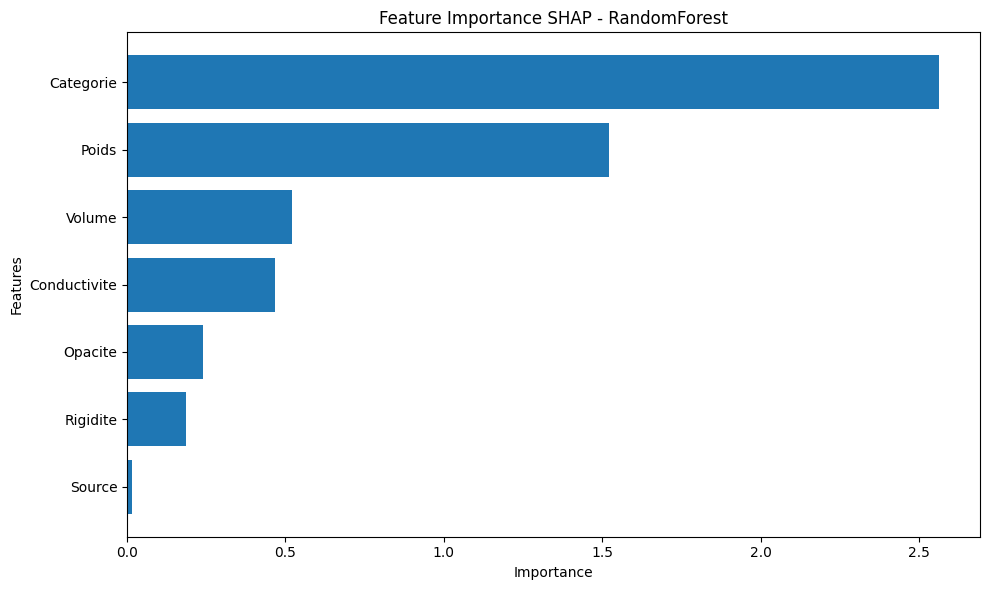

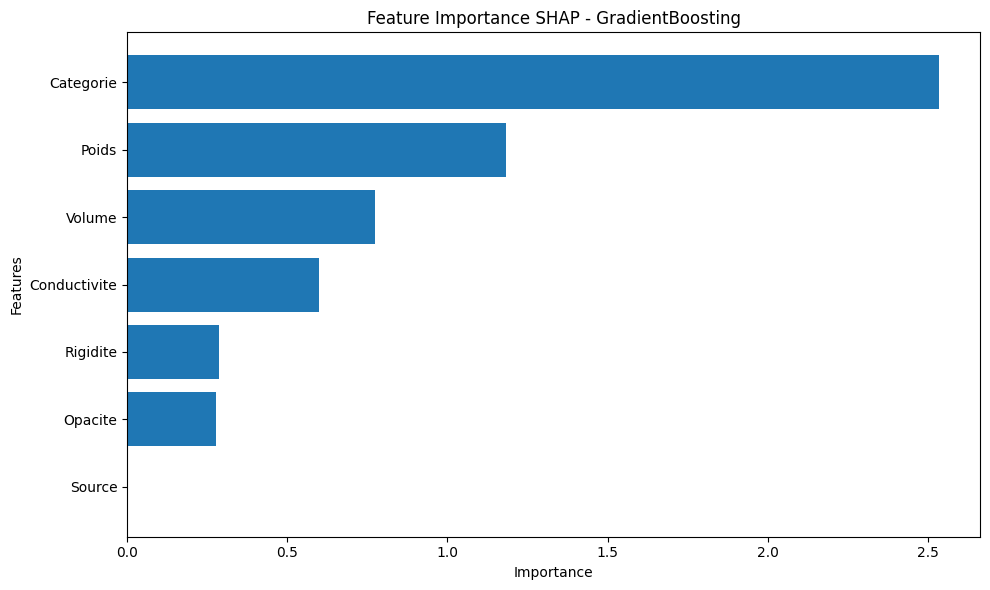

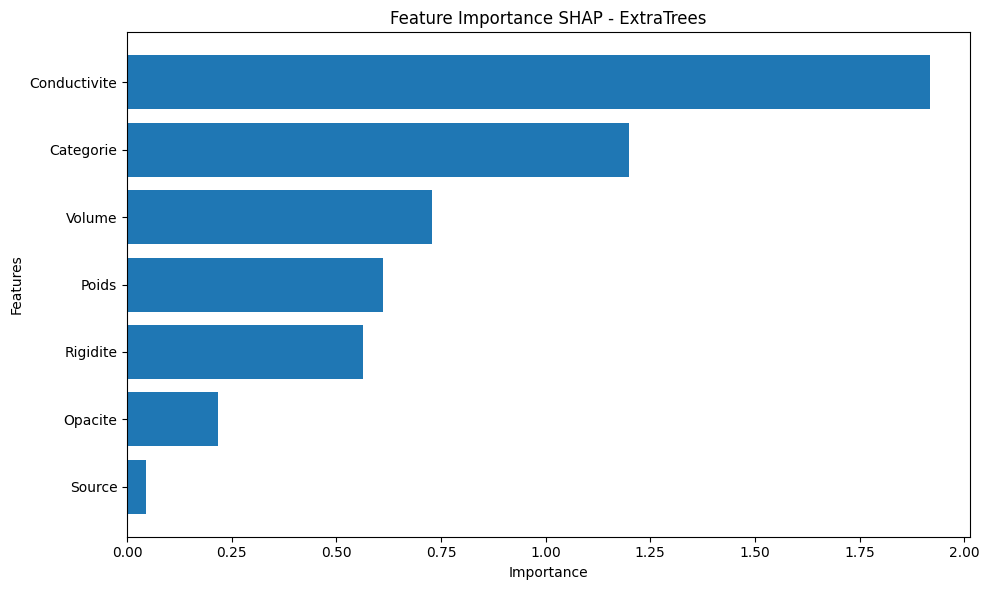

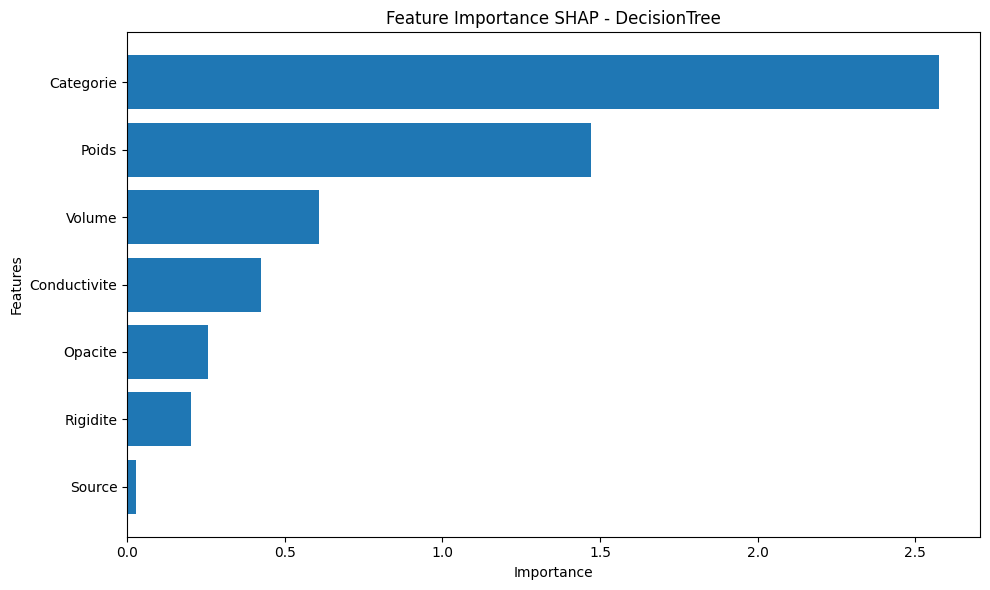

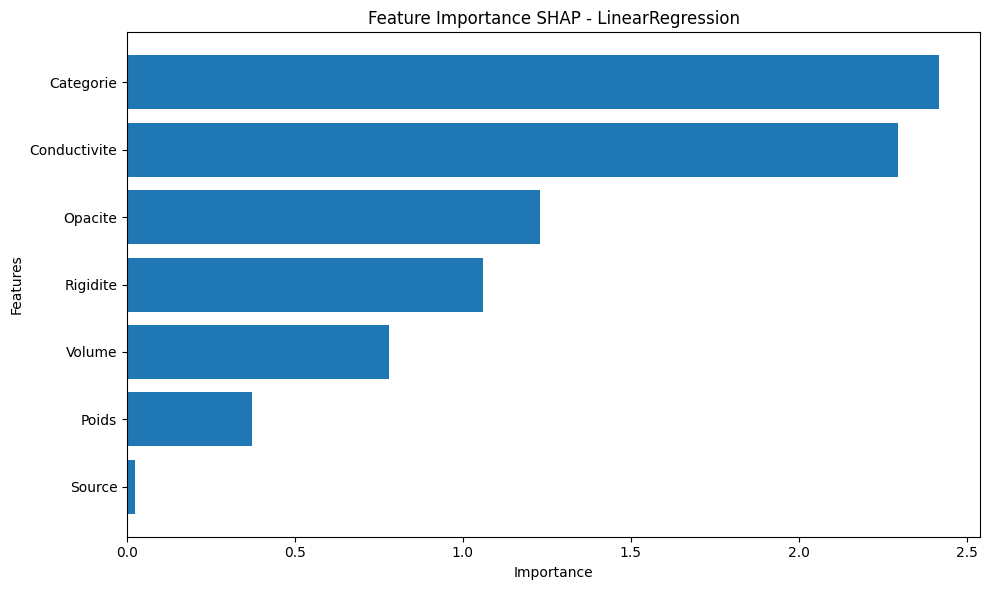

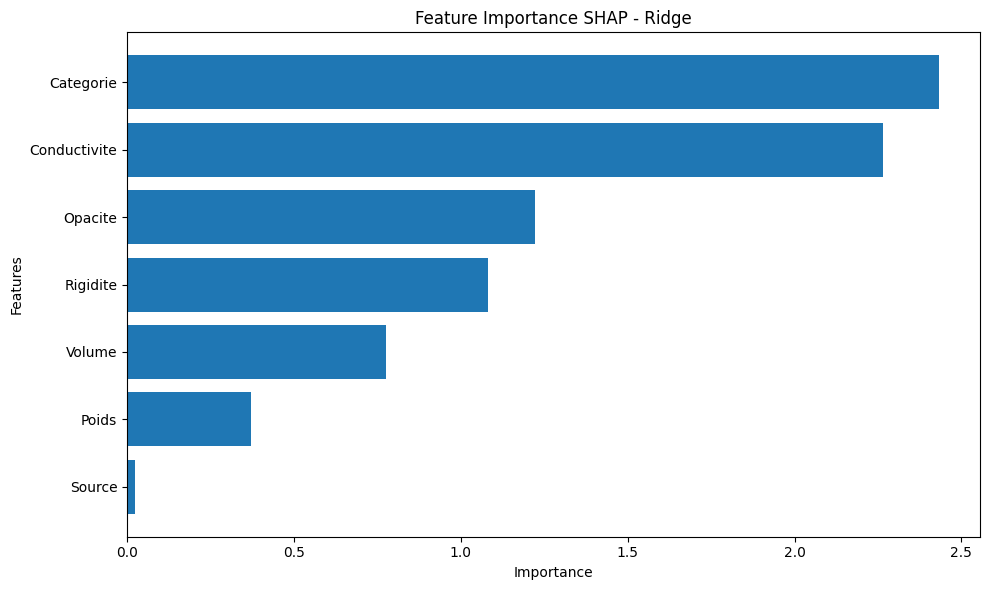

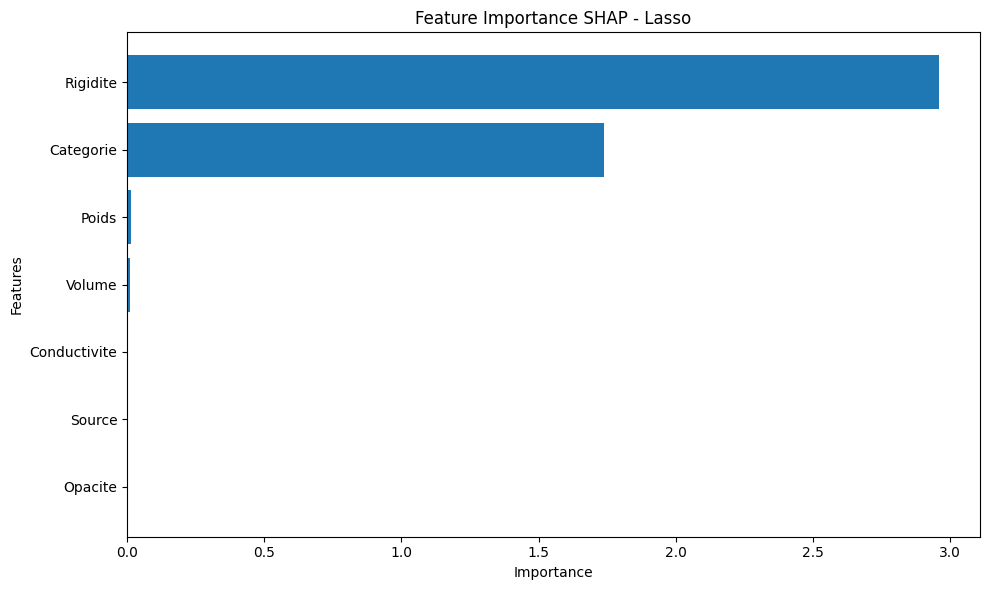

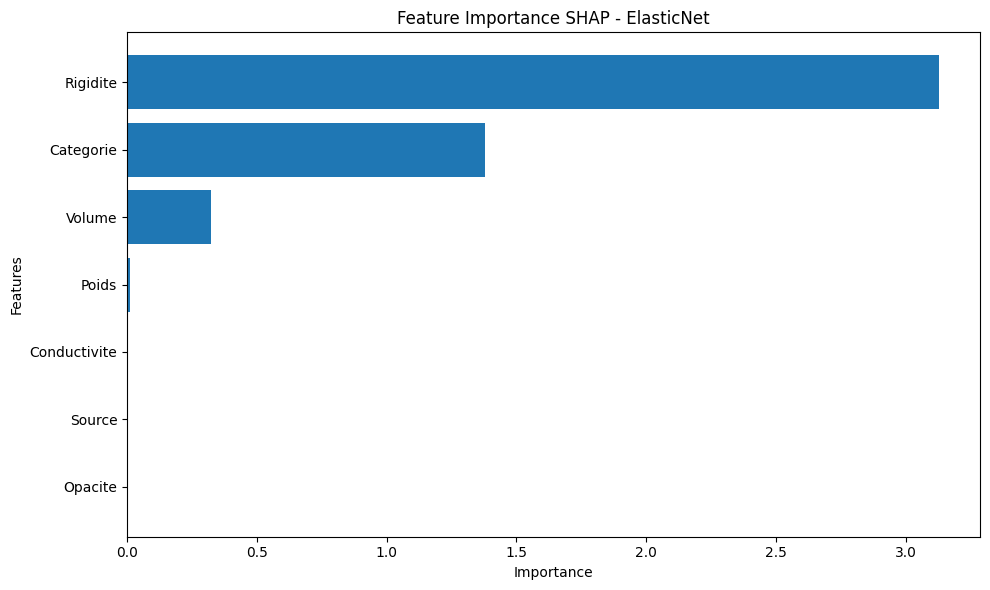

In [ ]:
import matplotlib.pyplot as plt

for model_name, feature_importance in shap_results.items():

    # Trier (sécurité)
    feature_importance = feature_importance.sort_values(by="importance", ascending=True)

    plt.figure(figsize=(10, 6))

    plt.barh(
        feature_importance["feature"],
        feature_importance["importance"]
    )

    plt.title(f"Feature Importance SHAP - {model_name}")
    plt.xlabel("Importance")
    plt.ylabel("Features")

    plt.tight_layout()
    plt.show()

In [ ]:
top_features_models = {}

for name, df_imp in shap_results.items():
    
    top_features = df_imp.head(10)["feature"].tolist()
    top_features_models[name] = top_features

    print(f"\nTop features - {name}:")
    print(top_features)


Top features - RandomForest:
['Categorie', 'Poids', 'Volume', 'Conductivite', 'Opacite', 'Rigidite', 'Source']

Top features - GradientBoosting:
['Categorie', 'Poids', 'Volume', 'Conductivite', 'Rigidite', 'Opacite', 'Source']

Top features - ExtraTrees:
['Conductivite', 'Categorie', 'Volume', 'Poids', 'Rigidite', 'Opacite', 'Source']

Top features - DecisionTree:
['Categorie', 'Poids', 'Volume', 'Conductivite', 'Opacite', 'Rigidite', 'Source']

Top features - LinearRegression:
['Categorie', 'Conductivite', 'Opacite', 'Rigidite', 'Volume', 'Poids', 'Source']

Top features - Ridge:
['Categorie', 'Conductivite', 'Opacite', 'Rigidite', 'Volume', 'Poids', 'Source']

Top features - Lasso:
['Rigidite', 'Categorie', 'Poids', 'Volume', 'Conductivite', 'Opacite', 'Source']

Top features - ElasticNet:
['Rigidite', 'Categorie', 'Volume', 'Poids', 'Conductivite', 'Opacite', 'Source']


In [ ]:
from collections import Counter

all_features = []

for feats in top_features_models.values():
    all_features.extend(feats)

feature_counts = Counter(all_features)

global_top_features = [f for f, c in feature_counts.most_common(10)]

print("\n=== Global Top Features (SHAP Consensus) ===")
print(global_top_features)


=== Global Top Features (SHAP Consensus) ===
['Categorie', 'Poids', 'Volume', 'Conductivite', 'Opacite', 'Rigidite', 'Source']


Shape X_train: (6806, 7)


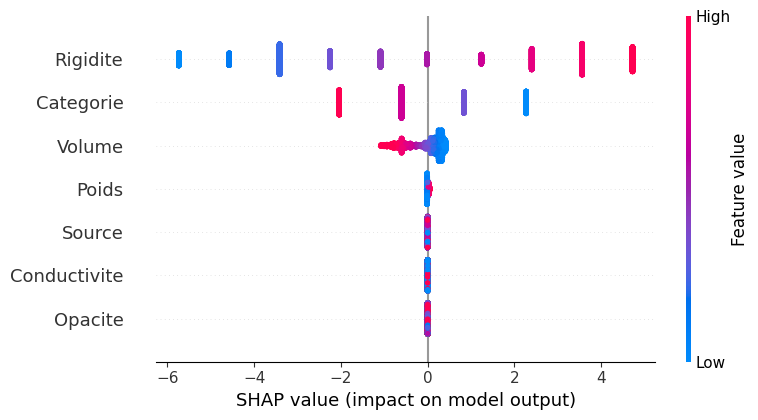

In [ ]:
X_train_shap = X_train[global_top_features]
X_test_shap = X_test[global_top_features]

print("Shape X_train:", X_train_shap.shape)

shap.summary_plot(shap_values, X_train)

# optuma multimodales

In [ ]:
import optuna
import numpy as np
import pandas as pd

def objective(trial, model_name):

    if model_name == "Ridge":
        model = Ridge(
            alpha=trial.suggest_float("alpha", 0.01, 10)
        )

    elif model_name == "Lasso":
        model = Lasso(
            alpha=trial.suggest_float("alpha", 0.001, 1)
        )

    elif model_name == "ElasticNet":
        model = ElasticNet(
            alpha=trial.suggest_float("alpha", 0.01, 1),
            l1_ratio=trial.suggest_float("l1_ratio", 0.1, 0.9)
        )


   

    elif model_name == "SVR":
        model = SVR(
            C=trial.suggest_float("C", 0.1, 10),
            epsilon=trial.suggest_float("epsilon", 0.01, 1),
            kernel="rbf"
        )



    # entraînement
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    return r2_score(y_test, y_pred)

In [ ]:
models = [
    "Ridge",
    "Lasso",
    "ElasticNet",
    "SVR",
]

results = []

for model_name in models:

    study = optuna.create_study(direction="maximize")

    study.optimize(lambda trial: objective(trial, model_name), n_trials=30)

    results.append({
        "model": model_name,
        "best_r2": study.best_value,
        "best_params": study.best_params
    })

    print(f"{model_name} OK ✔ Best R2 = {study.best_value:.4f}")

[I 2026-05-06 14:07:46,174] A new study created in memory with name: no-name-045d25ed-b648-4863-baa2-e30a7a945f7c
[I 2026-05-06 14:07:46,179] Trial 0 finished with value: 0.8721233255900772 and parameters: {'alpha': 2.242142400692901}. Best is trial 0 with value: 0.8721233255900772.
[I 2026-05-06 14:07:46,186] Trial 1 finished with value: 0.8712807249466009 and parameters: {'alpha': 7.137796718756529}. Best is trial 0 with value: 0.8721233255900772.
[I 2026-05-06 14:07:46,193] Trial 2 finished with value: 0.8714741806397395 and parameters: {'alpha': 6.164468648023497}. Best is trial 0 with value: 0.8721233255900772.
[I 2026-05-06 14:07:46,198] Trial 3 finished with value: 0.8719071071975144 and parameters: {'alpha': 3.712923030770079}. Best is trial 0 with value: 0.8721233255900772.
[I 2026-05-06 14:07:46,204] Trial 4 finished with value: 0.8719852681359642 and parameters: {'alpha': 3.2085887212632946}. Best is trial 0 with value: 0.8721233255900772.
[I 2026-05-06 14:07:46,209] Trial 5

Ridge OK ✔ Best R2 = 0.8724
Lasso OK ✔ Best R2 = 0.8723


[I 2026-05-06 14:07:46,504] Trial 3 finished with value: 0.7234428242531732 and parameters: {'alpha': 0.9394958799729966, 'l1_ratio': 0.11940290439990903}. Best is trial 0 with value: 0.8387423880808402.
[I 2026-05-06 14:07:46,510] Trial 4 finished with value: 0.7821129948013791 and parameters: {'alpha': 0.35853279349599565, 'l1_ratio': 0.3670601986548172}. Best is trial 0 with value: 0.8387423880808402.
[I 2026-05-06 14:07:46,513] Trial 5 finished with value: 0.8339858690550893 and parameters: {'alpha': 0.04891054880816945, 'l1_ratio': 0.6555671252137394}. Best is trial 0 with value: 0.8387423880808402.
[I 2026-05-06 14:07:46,517] Trial 6 finished with value: 0.7766705081602966 and parameters: {'alpha': 0.5376765221638132, 'l1_ratio': 0.8275189039473353}. Best is trial 0 with value: 0.8387423880808402.
[I 2026-05-06 14:07:46,524] Trial 7 finished with value: 0.739840983524379 and parameters: {'alpha': 0.7546529593974101, 'l1_ratio': 0.14786873905884754}. Best is trial 0 with value: 0.

ElasticNet OK ✔ Best R2 = 0.8620


[I 2026-05-06 14:07:48,163] Trial 0 finished with value: 0.8020521359185296 and parameters: {'C': 0.6776136745744745, 'epsilon': 0.2831723321735977}. Best is trial 0 with value: 0.8020521359185296.
[I 2026-05-06 14:07:49,490] Trial 1 finished with value: 0.8830231393571876 and parameters: {'C': 5.058772770756629, 'epsilon': 0.3725445807731915}. Best is trial 1 with value: 0.8830231393571876.
[I 2026-05-06 14:07:50,208] Trial 2 finished with value: 0.8660869559525386 and parameters: {'C': 3.3579781698572075, 'epsilon': 0.9885956843425683}. Best is trial 1 with value: 0.8830231393571876.
[I 2026-05-06 14:07:50,992] Trial 3 finished with value: 0.8440279508117716 and parameters: {'C': 1.9914422198682822, 'epsilon': 0.9213429342444585}. Best is trial 1 with value: 0.8830231393571876.
[I 2026-05-06 14:07:52,923] Trial 4 finished with value: 0.8819261459136736 and parameters: {'C': 5.037896221790387, 'epsilon': 0.0968366523521648}. Best is trial 1 with value: 0.8830231393571876.
[I 2026-05-0

SVR OK ✔ Best R2 = 0.9050


In [ ]:
results_df = pd.DataFrame(results).sort_values(by="best_r2", ascending=False)

print("\n=== COMPARAISON MODELS ===")
print(results_df)


=== COMPARAISON MODELS ===
        model   best_r2                                        best_params
3         SVR  0.905033  {'C': 9.919439018954577, 'epsilon': 0.52480214...
0       Ridge  0.872375                    {'alpha': 0.023468350958856354}
1       Lasso  0.872312                   {'alpha': 0.0014127882867803285}
2  ElasticNet  0.861995  {'alpha': 0.017462775543231494, 'l1_ratio': 0....


### GRAPHIQUE RÉELS vs PRÉDITS

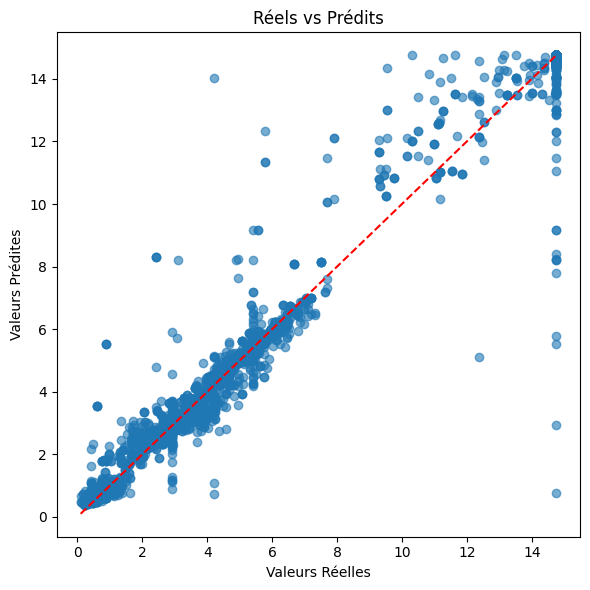

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))

plt.scatter(y_test, y_pred, alpha=0.6)

# ligne parfaite (y = x)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red', linestyle='--')

plt.xlabel("Valeurs Réelles")
plt.ylabel("Valeurs Prédites")
plt.title("Réels vs Prédits")

plt.tight_layout()
plt.show()